# ZORI ZIP-Code Data Cleaning & Prep

This notebook loads, reshapes, cleans, and enriches Zillow’s Observed Rent Index (ZORI) at the ZIP-code level.
These steps prepare the data for volatility modeling, seasonality analysis, and 3–12-month forecasting in later notebooks.

Primary tasks:

* <b>Load & reshape the wide-format ZORI dataset</b>

* <b>Assess and handle missingness in rent values</b>

* <b>Repair missing ZIP-level metadata (e.g., City)</b>

* <b>Engineer volatility features and export a clean dataset</b>

## 1. Imports & Setup

These packages support data loading (local + GCS), reshaping, visual diagnostics, and USPS ZIP lookup.

In [2]:
import pandas as pd
import numpy as np
import gcsfs
from joblib import Parallel, delayed
import seaborn as sns
import matplotlib.pyplot as plt
from uszipcode import SearchEngine

/opt/anaconda3/lib/python3.13/site-packages/fuzzywuzzy/fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


## 2. Load ZORI Data

We load Zillow’s ZIP-level time series directly from Google Cloud Storage. The source data is in wide format (one row per ZIP, one column per month).

In [3]:
fs = gcsfs.GCSFileSystem(project='cse6242-project-476314', token = 'google_default')
with fs.open('cse6242-project-data-bucket/Zip_zori_uc_sfrcondomfr_sm_sa_month.csv') as f:
    zori_wide = pd.read_csv(f, dtype={'RegionName': str})

# use local for initial testing
#zori_wide = pd.read_csv('Zip_zori_uc_sfrcondomfr_sm_sa_month.csv')
#zori_wide

# filter to southeastern US for demonstration purposes
southeast_states = ['AL', 'AR', 'FL', 'GA', 'KY', 'LA', 'MS', 'NC', 'SC', 'TN', 'VA', 'WV']

zori_wide = zori_wide[zori_wide['State'].isin(southeast_states)]

## 3. Reshape Data to Long Format

ZORI distributes months as separate columns.
We “melt” into long format for easier time-series operations.

Time-series forecasting, missingness analysis, and volatility calculations require one row per ZIP × month.

In [4]:
# get into long format
value_vars = [col for col in zori_wide.columns if col[:4].isdigit()]

zori = zori_wide.melt(
    id_vars=['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', 'State', 'City', 'Metro', 'CountyName'],
    value_vars = value_vars,
    var_name='Date',
    value_name='Rent'
)

# standardize date
zori['Date'] = pd.to_datetime(zori['Date'])
zori['Date'] = zori['Date'].dt.to_period('M').dt.to_timestamp('M')


# rename RegionID to ZIP
zori = zori.rename(columns={'RegionName':'ZIP'})

# sort time series
zori = zori.sort_values(['ZIP', 'Date'])

zori

,RegionID,SizeRank,ZIP,RegionType,StateName,State,City,Metro,CountyName,Date,Rent
813,66207,3417,20105,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2015-01-31,NaN
2858,66207,3417,20105,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2015-02-28,NaN
4903,66207,3417,20105,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2015-03-31,NaN
6948,66207,3417,20105,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2015-04-30,NaN
8993,66207,3417,20105,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2015-05-31,NaN
...,...,...,...,...,...,...,...,...,...,...,...
254308,89835,3084,72956,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,2025-05-31,1211.191244
256353,89835,3084,72956,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,2025-06-30,1209.091088
258398,89835,3084,72956,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,2025-07-31,1212.562577
260443,89835,3084,72956,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,2025-08-31,1201.858889


## 4. Inspect Data Structure & Missingness

### 4.1 Basic structure

In [5]:
zori.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263805 entries, 813 to 262488
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   RegionID    263805 non-null  int64         
 1   SizeRank    263805 non-null  int64         
 2   ZIP         263805 non-null  object        
 3   RegionType  263805 non-null  object        
 4   StateName   263805 non-null  object        
 5   State       263805 non-null  object        
 6   City        261483 non-null  object        
 7   Metro       262902 non-null  object        
 8   CountyName  263805 non-null  object        
 9   Date        263805 non-null  datetime64[ns]
 10  Rent        114768 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(7)
memory usage: 24.2+ MB


In [6]:
zori.describe()

,RegionID,SizeRank,Date,Rent
count,263805.000000,263805.000000,263805,114768.000000
mean,76724.645966,4799.284597,2020-05-30 20:39:04.186046720,1625.473895
min,66207.000000,15.000000,2015-01-31 00:00:00,573.644897
25%,70491.000000,2209.000000,2017-09-30 00:00:00,1248.422715
50%,72335.000000,4328.000000,2020-05-31 00:00:00,1542.463660
75%,73588.000000,6813.000000,2023-01-31 00:00:00,1892.072640
max,787972.000000,30172.000000,2025-09-30 00:00:00,10325.383925
std,38460.280659,3371.395656,NaN,593.038095


### 4.2 Missing values count

In [7]:
zori.isna().sum()

RegionID           0
SizeRank           0
ZIP                0
RegionType         0
StateName          0
State              0
City            2322
Metro            903
CountyName         0
Date               0
Rent          149037
dtype: int64

## 5. Missingness Analysis

### 5.1 Detect inconsistent gaps
Check if any ZIPs skip months (should be monthly frequency):

In [8]:
# spacing
zori['gap_days']  = zori.groupby('ZIP')['Date'].diff().dt.days
anomalies = zori[zori['gap_days'] > 31]
anomalies.head()

,RegionID,SizeRank,ZIP,RegionType,StateName,State,City,Metro,CountyName,Date,Rent,gap_days


### 5.2 Standardize the Time Index
We reindex all ZIPs to a complete, uniform timeline:

<b>Jan-2015 through Dec-2024.</b>

This ensures every ZIP has the same number of rows.

In [9]:
full_index = pd.date_range('2015-01-01', '2024-12-01', freq='ME')

zori2 = zori.copy()
zori2['Date'] = pd.to_datetime(zori2['Date']).dt.to_period('M').dt.to_timestamp('M')

zori2 = (
    zori2
    .set_index('Date')
    .groupby('ZIP')
    .apply(lambda x: x.drop(columns='ZIP').reindex(full_index)) 
    .rename_axis(index=['ZIP', 'Date'])
    .reset_index()  
)

zori2

/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_32062/3203717608.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.drop(columns='ZIP').reindex(full_index))


,ZIP,Date,RegionID,SizeRank,RegionType,StateName,State,City,Metro,CountyName,Rent,gap_days
0,20105,2015-01-31,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,NaN,NaN
1,20105,2015-02-28,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,NaN,28.0
2,20105,2015-03-31,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,NaN,31.0
3,20105,2015-04-30,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,NaN,30.0
4,20105,2015-05-31,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,NaN,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...
243350,72956,2024-07-31,89835,3084,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,NaN,31.0
243351,72956,2024-08-31,89835,3084,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,NaN,31.0
243352,72956,2024-09-30,89835,3084,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,NaN,30.0
243353,72956,2024-10-31,89835,3084,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,NaN,31.0


### 5.3 Missingness by State and Month

This helps us understand geographic and temporal patterns in missing ZORI values.

In [10]:
zip_missing = (
    zori2.groupby(['State', 'ZIP'])['Rent']
        .apply(lambda s: s.isna().sum())
        .reset_index(name='missing')
)

zip_missing.groupby('State')['missing'].apply(lambda x: (x > 0).mean()).sort_values()

State
FL    0.771982
GA    0.810700
VA    0.859223
NC    0.874459
TN    0.945578
SC    0.957983
AR    0.983051
AL    1.000000
KY    1.000000
LA    1.000000
MS    1.000000
WV    1.000000
Name: missing, dtype: float64

### 5.3 Visualize ZIP x Time Missingness

In [11]:
missing_by_month = (
    zori2.groupby('Date')['Rent']
        .apply(lambda s: s.isna().mean())
        .reset_index(name='pct_missing')
)

missing_by_month

,Date,pct_missing
0,2015-01-31,0.839120
1,2015-02-28,0.837164
2,2015-03-31,0.827873
3,2015-04-30,0.826895
4,2015-05-31,0.822983
...,...,...
114,2024-07-31,0.235208
115,2024-08-31,0.237653
116,2024-09-30,0.232274
117,2024-10-31,0.221516


<Axes: xlabel='Date'>

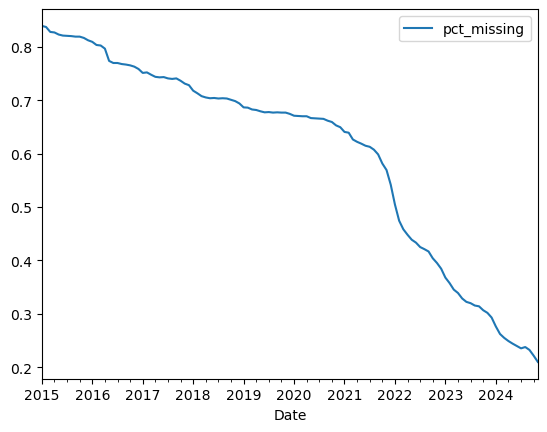

In [12]:
missing_by_month.plot(x='Date', y='pct_missing')

In [13]:
def missing_streak_length(series):
    return series.isna().groupby((~series.isna()).cumsum()).sum().max()

zip_missing_streak = (
    zori2.groupby('ZIP')['Rent']
        .apply(missing_streak_length)
        .reset_index(name='max_missing_streak')
)

zip_missing_streak.sort_values('max_missing_streak', ascending=False).head()

,ZIP,max_missing_streak
1022,32952,119
945,32615,119
947,32656,119
967,32766,119
970,32776,119


Text(0.5, 1.0, 'Missing Rent Data by ZIP × Month')

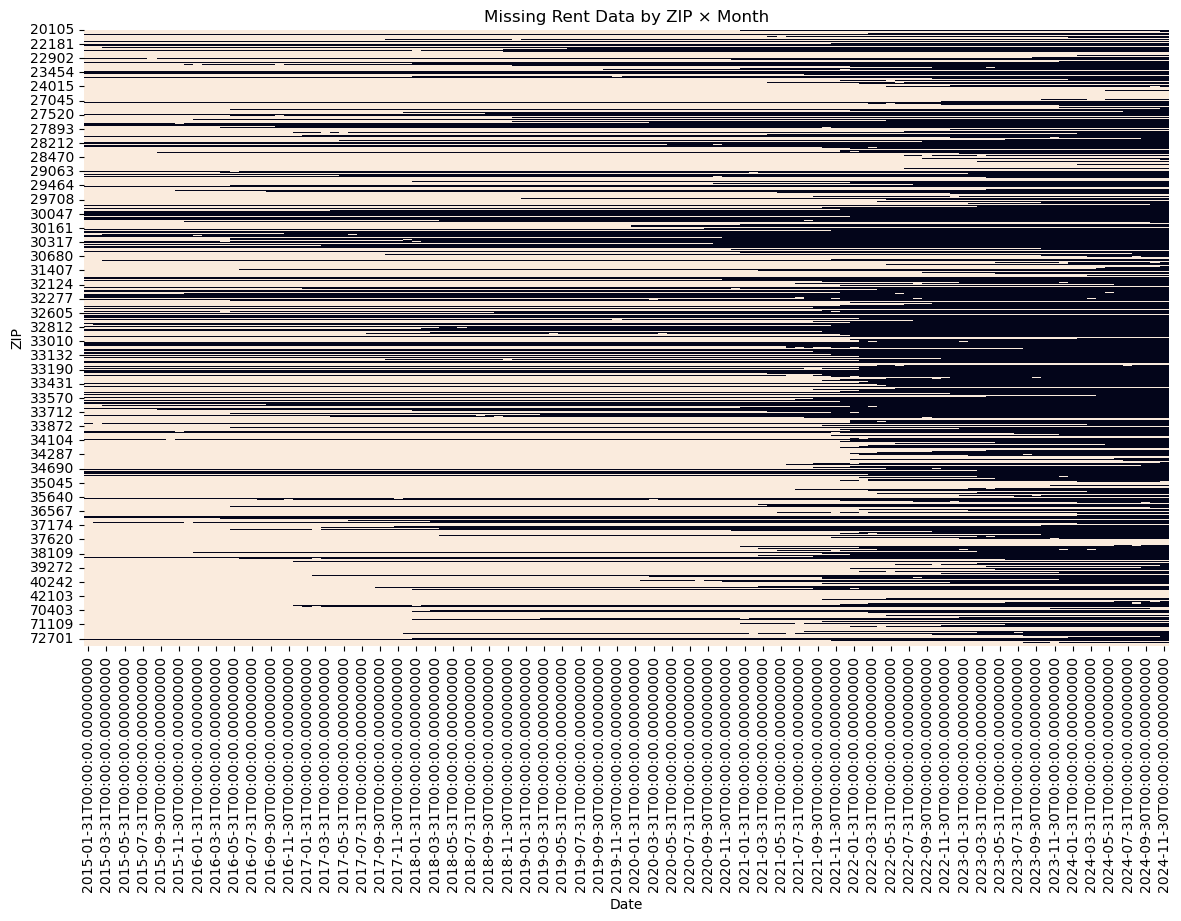

In [14]:
sample = zori2.pivot(index='ZIP', columns='Date', values='Rent')
plt.figure(figsize=(14,8))
sns.heatmap(sample.isna(), cbar=False)
plt.title("Missing Rent Data by ZIP × Month")

## 6. Impute Missing Rent Values

We use linear interpolation within each ZIP.

<b>Why linear interpolation?</b>

* Avoids distortions in seasonal decomposition
* Preserves month-to-month smoothness
* Works well for ZORI, which is already smoothed by Zillow

In [15]:
def interpolate_zip(series):
    s = series.astype(float).copy()

    return s.interpolate(method='linear', limit_direction='both')

Apply per ZIP:

In [16]:
df_interpolated = (
    zori2
        .groupby('ZIP', group_keys=False)
        .apply(lambda g: g.assign(Rent=interpolate_zip(g['Rent'])))
        .reset_index(drop=True)
)

/var/folders/v6/rt7shrqx5sldb75bkwymnhlw0000gp/T/ipykernel_32062/3954869825.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.assign(Rent=interpolate_zip(g['Rent'])))


In [17]:
df_interpolated

,ZIP,Date,RegionID,SizeRank,RegionType,StateName,State,City,Metro,CountyName,Rent,gap_days
0,20105,2015-01-31,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,NaN
1,20105,2015-02-28,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,28.0
2,20105,2015-03-31,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,31.0
3,20105,2015-04-30,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,30.0
4,20105,2015-05-31,66207,3417,zip,VA,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,31.0
...,...,...,...,...,...,...,...,...,...,...,...,...
243350,72956,2024-07-31,89835,3084,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,NaN,31.0
243351,72956,2024-08-31,89835,3084,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,NaN,31.0
243352,72956,2024-09-30,89835,3084,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,NaN,30.0
243353,72956,2024-10-31,89835,3084,zip,AR,AR,Van Buren,"Fort Smith, AR-OK",Crawford County,NaN,31.0


### 6.1 Identify ZIP Codes with Unreliable Imputation

Compute the longest consecutive missing streak before interpolation:

In [18]:
df_interpolated['missing_after'] = df_interpolated.groupby('ZIP')['Rent'].transform(lambda s: s.isna().sum())

missing_summary = (
    df_interpolated.groupby('ZIP')['Rent']
         .apply(lambda s: s.isna().sum())
         .reset_index(name='missing_count')
)

# How many ZIPs have missing values?
num_zip_with_missing = (missing_summary['missing_count'] > 0).sum()

num_zip_with_missing

np.int64(422)

In [19]:
# proportion of missing vs total zips
total_zips = missing_summary.shape[0]
percentage = num_zip_with_missing / total_zips * 100
percentage

np.float64(20.635696821515893)

Drop ZIPs with > 24 consecutive missing months.

In [20]:
def longest_gap(s):
    mask = s.isna()
    return mask.groupby((~mask).cumsum()).sum().max()

zip_bad = (
    df_interpolated.groupby('ZIP')['Rent']
                   .apply(longest_gap)
                   .reset_index(name='longest_gap')
)

good_zips = zip_bad[zip_bad['longest_gap'] <= 24]['ZIP']

good_zips.nunique()

1623

In [21]:
df_interpolated_final = df_interpolated[df_interpolated['ZIP'].isin(good_zips)].copy()

## 7. Repair Missing City Names

USPS provides a reliable primary city for each ZIP.

In [22]:
search = SearchEngine()

def get_city(zipcode):
    z = search.by_zipcode(zipcode)
    return z.major_city

In [23]:
# Get the primary city for each ZIP code
df_interpolated_final.loc[:, 'ZIP'] = (
    df_interpolated_final['ZIP']
        .astype(str)
        .str.zfill(5)   # fix any that aren't padded correctly 1002 -> 01002
)

unique_zips = df_interpolated_final['ZIP'].drop_duplicates()

zip_city_map = {
    z: get_city(z) for z in unique_zips
}

df_interpolated_final.loc[:, 'City'] = df_interpolated_final['ZIP'].map(zip_city_map)

In [24]:
df_interpolated_final.isna().sum()

ZIP                 0
Date                0
RegionID            0
SizeRank            0
RegionType          0
StateName           0
State               0
City                0
Metro               0
CountyName          0
Rent                0
gap_days         1623
missing_after       0
dtype: int64

## 8. Feature Engineering

### 8.1 Month-over-month % Change

In [25]:
df_interpolated_final.loc[:, 'pct_change'] = (df_interpolated_final.groupby('ZIP')['Rent'].transform(lambda s: s.pct_change()))

### 8.2 Rolling 12-month Volatility

This is the standard deviation of percent changes.

In [26]:
df_interpolated_final.loc[:, 'Volatility'] = (df_interpolated_final.groupby('ZIP')['pct_change'].transform(lambda s: s.rolling(12, min_periods=6).std()))

## 9. Final Cleaning and Export

In [27]:
df_final = df_interpolated_final.copy()
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193137 entries, 0 to 242878
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   ZIP            193137 non-null  object        
 1   Date           193137 non-null  datetime64[ns]
 2   RegionID       193137 non-null  int64         
 3   SizeRank       193137 non-null  int64         
 4   RegionType     193137 non-null  object        
 5   StateName      193137 non-null  object        
 6   State          193137 non-null  object        
 7   City           193137 non-null  object        
 8   Metro          193137 non-null  object        
 9   CountyName     193137 non-null  object        
 10  Rent           193137 non-null  float64       
 11  gap_days       191514 non-null  float64       
 12  missing_after  193137 non-null  int64         
 13  pct_change     191514 non-null  float64       
 14  Volatility     183399 non-null  float64       
dtypes: da

Drop intermediate columns:

In [28]:
cols_to_drop = ['StateName', 'gap_days', 'missing_after', 'pct_change']
df_final = df_final.drop(columns=cols_to_drop)
df_final.head()

,ZIP,Date,RegionID,SizeRank,RegionType,State,City,Metro,CountyName,Rent,Volatility
0,20105,2015-01-31,66207,3417,zip,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,NaN
1,20105,2015-02-28,66207,3417,zip,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,NaN
2,20105,2015-03-31,66207,3417,zip,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,NaN
3,20105,2015-04-30,66207,3417,zip,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,NaN
4,20105,2015-05-31,66207,3417,zip,VA,Aldie,"Washington-Arlington-Alexandria, DC-VA-MD-WV",Loudoun County,2969.21911,NaN


Export:

In [31]:
df_final.to_csv('../data/processed/clean_zori_se.csv', index=False)
df_final.to_parquet('../data/processed/clean_zori_se.parquet', index=False, compression='snappy')

df_sarimax = df_final.rename(columns={
    "ZIP": "zip",
    "State": "state",
    "Date": "date",
    "Rent": "zori_smoothed_seasonal"
})

df_sarimax.to_parquet(
    "../data/processed/clean_zori_sarimax_se.parquet",
    index=False,
    compression="snappy"
)